# Week 6 Assignment

## Image Denoising using Autoencoder on MNIST Dataset


In [17]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

## Device Configuration

The model checks whether a GPU is available. If CUDA is available, the model is trained on the GPU; otherwise, it runs on the CPU.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Loading the MNIST Dataset

The MNIST dataset is loaded and converted into tensors. It contains grayscale images of handwritten digits from 0 to 9. Separate datasets are used for training and testing.

In [19]:
transform = transforms.ToTensor()

train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(len(train_data), len(test_data))

60000 10000


## Creating Data Loaders
Data loaders are created to load the images in batches during training and testing. This helps in efficient training and reduces memory usage.

In [20]:
batch_size = 128

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Visualizing Sample Images

Before training the model, a few sample images from the dataset are displayed to understand the input data.

torch.Size([128, 1, 28, 28]) torch.Size([128])


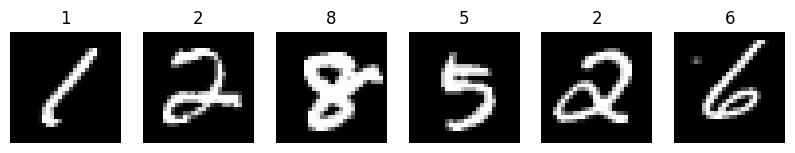

In [21]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(imgs[i][0], cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.show()

## Adding Noise to Images

Random Gaussian noise is added to the original images. These noisy images are given as input to the autoencoder, while the original clean images are used as the target output.

In [22]:
noise_factor = 0.4

def add_noise(imgs):
    noisy = imgs + noise_factor * torch.randn(*imgs.shape)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

## Comparing Original and Noisy Images

This section displays the original images along with their noisy versions. This helps in understanding the effect of the added noise.

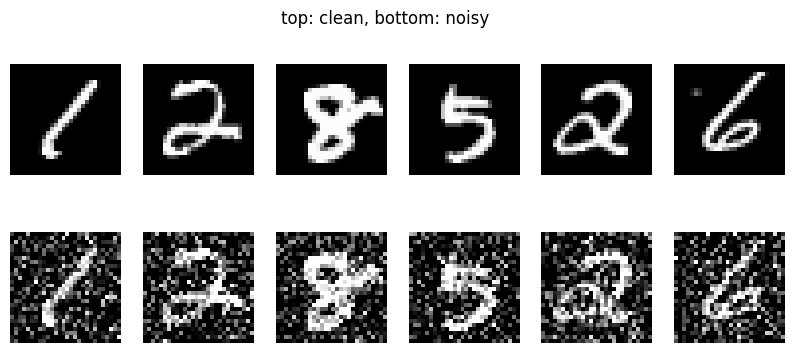

In [23]:
noisy_imgs = add_noise(imgs)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i in range(6):
    axes[0][i].imshow(imgs[i][0], cmap='gray')
    axes[0][i].axis('off')
    axes[1][i].imshow(noisy_imgs[i][0], cmap='gray')
    axes[1][i].axis('off')
plt.suptitle('top: clean, bottom: noisy')
plt.show()

## Building the Autoencoder

The autoencoder consists of two main parts:

 **Encoder:** Compresses the input image into a smaller representation.
**Decoder:** Reconstructs the image from the compressed representation.

The model is trained to minimize the difference between the reconstructed image and the original clean image.

In [24]:
w_enc1 = torch.randn(32, 1, 3, 3, device=device) * 0.1
b_enc1 = torch.zeros(32, device=device)
w_enc2 = torch.randn(16, 32, 3, 3, device=device) * 0.1
b_enc2 = torch.zeros(16, device=device)
w_dec1 = torch.randn(16, 32, 2, 2, device=device) * 0.1
b_dec1 = torch.zeros(32, device=device)
w_dec2 = torch.randn(32, 1, 2, 2, device=device) * 0.1
b_dec2 = torch.zeros(1, device=device)
params = [w_enc1, b_enc1, w_enc2, b_enc2, w_dec1, b_dec1, w_dec2, b_dec2]
for p in params:
    p.requires_grad_(True)
n_params = sum(p.numel() for p in params)
print(f'total params: {n_params:,}')

total params: 7,153


## Training Configuration

The Adam optimizer is used for updating the model parameters, and Mean Squared Error (MSE) is used as the loss function because this is an image reconstruction task.

In [25]:
def forward(x):
    x = F.conv2d(x, w_enc1, b_enc1, padding=1)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = F.conv2d(x, w_enc2, b_enc2, padding=1)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = F.conv_transpose2d(x, w_dec1, b_dec1, stride=2)
    x = F.relu(x)
    x = F.conv_transpose2d(x, w_dec2, b_dec2, stride=2)
    x = torch.sigmoid(x)
    return x

In [26]:
optimizer = torch.optim.Adam(params, lr=1e-3)
num_epochs = 15

## Model Training

The model is trained for multiple epochs. During each epoch, noisy images are passed through the autoencoder, the reconstruction loss is calculated, and the parameters are updated using backpropagation.

In [27]:
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs).to(device)

        optimizer.zero_grad()
        outputs = forward(noisy_imgs)
        loss = ((outputs - imgs) ** 2).mean()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_data)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f}')

Epoch 1/15 - loss: 0.0653
Epoch 2/15 - loss: 0.0170
Epoch 3/15 - loss: 0.0138
Epoch 4/15 - loss: 0.0130
Epoch 5/15 - loss: 0.0125
Epoch 6/15 - loss: 0.0122
Epoch 7/15 - loss: 0.0119
Epoch 8/15 - loss: 0.0117
Epoch 9/15 - loss: 0.0116
Epoch 10/15 - loss: 0.0114
Epoch 11/15 - loss: 0.0113
Epoch 12/15 - loss: 0.0112
Epoch 13/15 - loss: 0.0112
Epoch 14/15 - loss: 0.0111
Epoch 15/15 - loss: 0.0110


## Training Loss

The graph below shows how the reconstruction loss changes over different epochs. A decreasing loss indicates that the model is learning to reconstruct cleaner images.

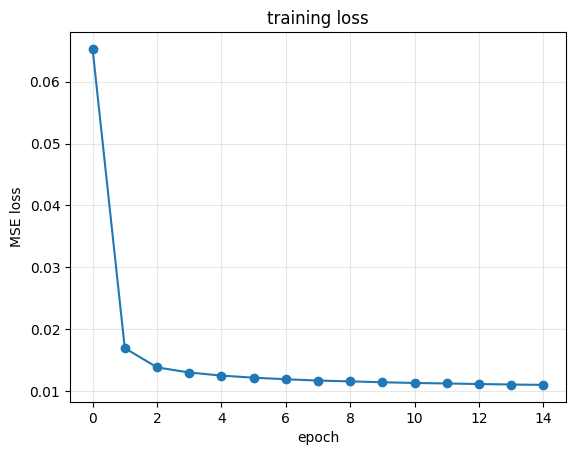

In [28]:
plt.plot(train_losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('training loss')
plt.grid(alpha=0.3)
plt.show()

## Testing the Autoencoder

The trained model is tested using unseen images from the test dataset. Noisy images are passed through the model to generate denoised outputs.

In [29]:
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs.to(device)
noisy_test = add_noise(test_imgs).to(device)

with torch.no_grad():
    denoised = forward(noisy_test)

test_imgs = test_imgs.cpu()
noisy_test = noisy_test.cpu()
denoised = denoised.cpu()

## Result Visualization

The following images compare:

1. Original image
2. Noisy image
3. Reconstructed (denoised) image

The reconstructed images show that the autoencoder has learned to remove most of the noise while preserving the handwritten digits.

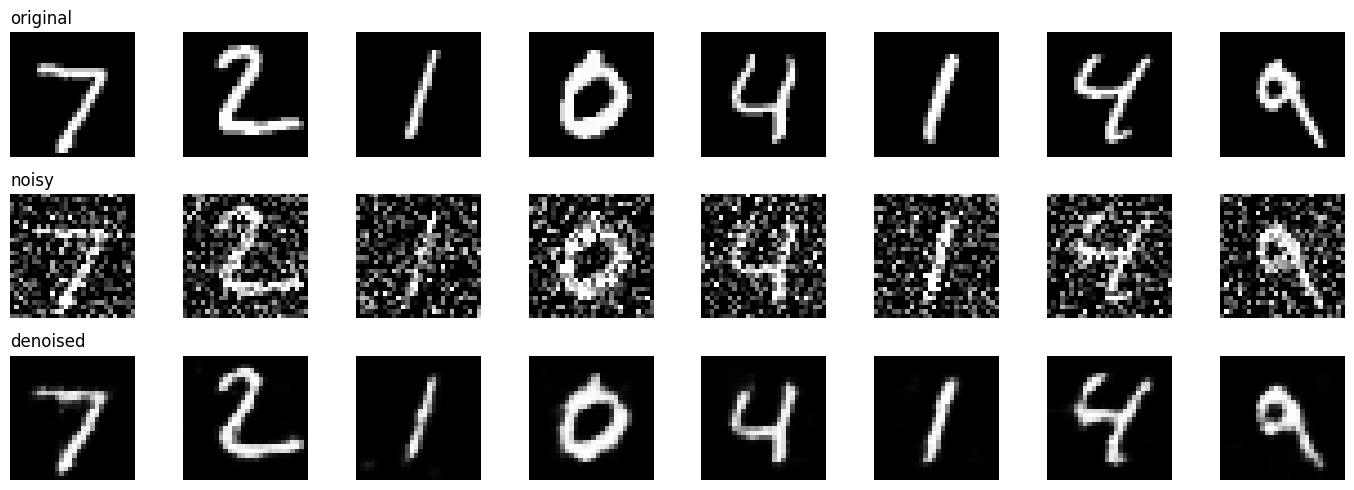

In [30]:
n = 8
fig, axes = plt.subplots(3, n, figsize=(14, 5))

for i in range(n):
    axes[0][i].imshow(test_imgs[i][0], cmap='gray')
    axes[0][i].axis('off')
    axes[1][i].imshow(noisy_test[i][0], cmap='gray')
    axes[1][i].axis('off')
    axes[2][i].imshow(denoised[i][0], cmap='gray')
    axes[2][i].axis('off')

axes[0][0].set_title('original', loc='left')
axes[1][0].set_title('noisy', loc='left')
axes[2][0].set_title('denoised', loc='left')
plt.tight_layout()
plt.show()

## Model Evaluation

The average Mean Squared Error (MSE) is calculated to compare the noisy images and the reconstructed images with the original images. A lower MSE after reconstruction indicates better denoising performance.

In [31]:
def avg_mse(a, b):
    return ((a - b) ** 2).mean().item()

total_noisy_mse = 0.0
total_denoised_mse = 0.0
n_batches = 0

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        noisy = add_noise(imgs).to(device)
        denoised_batch = forward(noisy)

        total_noisy_mse += avg_mse(noisy, imgs)
        total_denoised_mse += avg_mse(denoised_batch, imgs)
        n_batches += 1

print(f'avg MSE, noisy vs clean:    {total_noisy_mse / n_batches:.4f}')
print(f'avg MSE, denoised vs clean: {total_denoised_mse / n_batches:.4f}')

avg MSE, noisy vs clean:    0.0797
avg MSE, denoised vs clean: 0.0109
